In [3]:
  import pandas as pd                                                                                   
  import numpy as np                                                                                    
  import matplotlib.pyplot as plt                                                                       
  import seaborn as sns                                                                                 
                                                                                                        
  pd.set_option('display.max_columns', None)
                                                                                                        
  train = pd.read_csv('../data/train_data.csv')                                                       
  test = pd.read_csv('../data/test_data.csv')

  print("Train shape:", train.shape)
  print("Test shape:", test.shape)

Train shape: (3200, 23)
Test shape: (3200, 22)


In [4]:
train.head()

,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,0.00088,0,0,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,0.00510,0,0,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,0.00020,0,1,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,0.00720,0,0,0,0.10400,0,0,0,0,0,0.116,0,class2


In [6]:
  print(train.dtypes)                                                                                   
  print("\nMissing values in train:")                                                                 
  print(train.isnull().sum())

ID          int64
f1        float64
f2        float64
f3          int64
f4          int64
f5          int64
f6          int64
f7          int64
f8          int64
f9        float64
f10       float64
f11         int64
f12         int64
f13         int64
f14       float64
f15         int64
f16         int64
f17         int64
f18         int64
f19         int64
f20       float64
f21         int64
target     object
dtype: object

Missing values in train:
ID        0
f1        0
f2        0
f3        0
f4        0
f5        0
f6        0
f7        0
f8        0
f9        0
f10       0
f11       0
f12       0
f13       0
f14       0
f15       0
f16       0
f17       0
f18       0
f19       0
f20       0
f21       0
target    0
dtype: int64


In [8]:
  int_cols = train.select_dtypes(include='int64').drop(columns='ID').columns                          

  for col in int_cols:
      print(f"{col}: {sorted(train[col].unique())}")

f3: [np.int64(0), np.int64(1)]
f4: [np.int64(0), np.int64(1)]
f5: [np.int64(0), np.int64(1)]
f6: [np.int64(0), np.int64(1)]
f7: [np.int64(0), np.int64(1)]
f8: [np.int64(0), np.int64(1)]
f11: [np.int64(0), np.int64(1)]
f12: [np.int64(0), np.int64(1)]
f13: [np.int64(0), np.int64(1)]
f15: [np.int64(0), np.int64(1)]
f16: [np.int64(0), np.int64(1)]
f17: [np.int64(0), np.int64(1)]
f18: [np.int64(0), np.int64(1)]
f19: [np.int64(0), np.int64(1)]
f21: [np.int64(0), np.int64(1)]


In [10]:
  print(train['target'].value_counts())
  print("\nProportions:")
  print(train['target'].value_counts(normalize=True).round(3))

target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Proportions:
target
class3    0.911
class2    0.060
class1    0.029
Name: proportion, dtype: float64


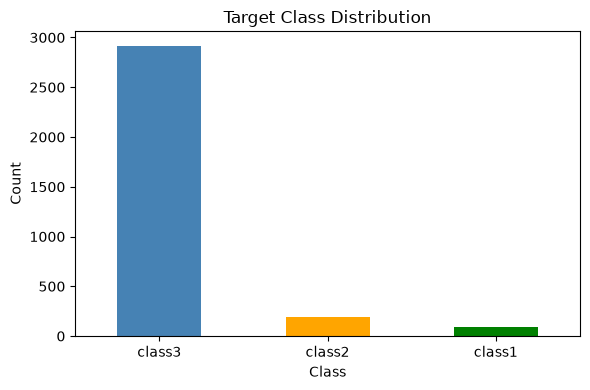

In [11]:
  plt.figure(figsize=(6, 4))
  train['target'].value_counts().plot(kind='bar', color=['steelblue', 'orange', 'green'])
  plt.title('Target Class Distribution')
  plt.xlabel('Class')
  plt.ylabel('Count')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

In [12]:
  continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']                                             
  train[continuous_cols].describe().round(4)  

,f1,f2,f9,f10,f14,f20
count,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000
mean,0.5169,0.0201,0.1080,0.0052,0.1099,0.0992
std,0.1898,0.0075,0.0352,0.0251,0.0343,0.0185
min,0.0100,0.0005,0.0020,0.0000,0.0020,0.0190
25%,0.3600,0.0170,0.0880,0.0005,0.0930,0.0890
50%,0.5400,0.0206,0.1050,0.0016,0.1080,0.0990
75%,0.6700,0.0230,0.1220,0.0024,0.1220,0.1070
max,0.9400,0.1059,0.4300,0.5300,0.6120,0.2320


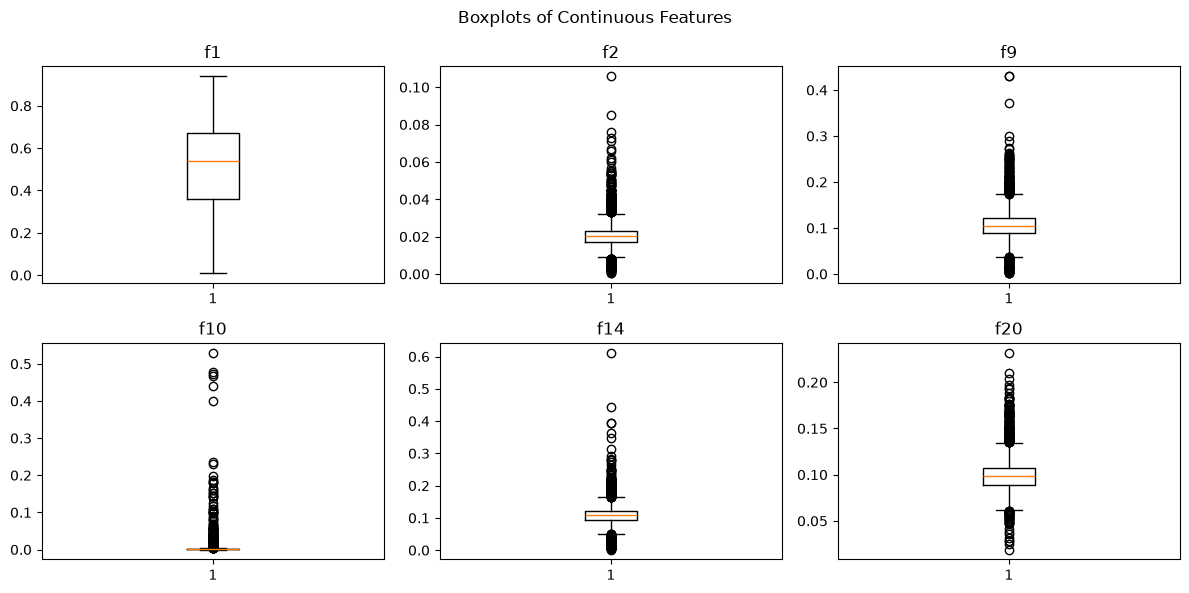

In [14]:
  fig, axes = plt.subplots(2, 3, figsize=(12, 6))
  axes = axes.flatten()

  for i, col in enumerate(continuous_cols):
      axes[i].boxplot(train[col])
      axes[i].set_title(col)

  plt.suptitle('Boxplots of Continuous Features')
  plt.tight_layout()
  plt.show()

In [16]:
  train.groupby('target')[continuous_cols].mean().round(4)                                              

,f1,f2,f9,f10,f14,f20
target,,,,,,
class1,0.4987,0.0097,0.0338,0.0934,0.0330,0.1038
class2,0.5243,0.0175,0.0916,0.0140,0.0921,0.1000
class3,0.5170,0.0206,0.1114,0.0018,0.1135,0.0990


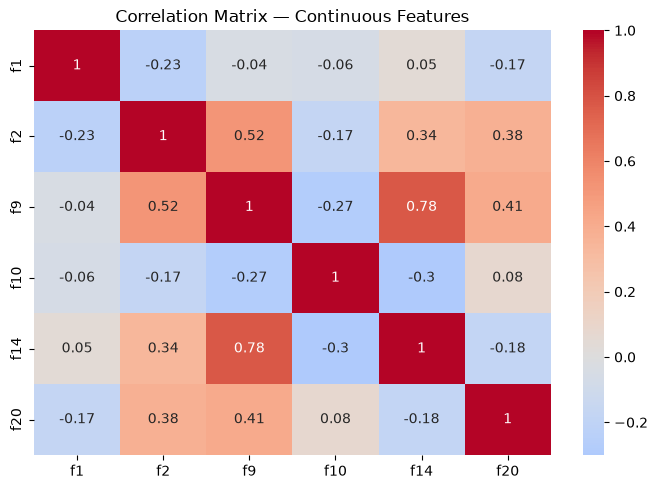

In [18]:
  plt.figure(figsize=(7, 5))                                                                            
  sns.heatmap(train[continuous_cols].corr().round(2), annot=True, cmap='coolwarm', center=0)            
  plt.title('Correlation Matrix — Continuous Features')                                                 
  plt.tight_layout()                                                                                    
  plt.show()   

In [19]:
  binary_cols = [col for col in train.columns if col not in continuous_cols + ['ID', 'target']]         
                                                                                                        
  train.groupby('target')[binary_cols].mean().round(3)  

,f3,f4,f5,f6,f7,f8,f11,f12,f13,f15,f16,f17,f18,f19,f21
target,,,,,,,,,,,,,,,
class1,0.000,0.237,0.022,0.000,0.000,0.000,0.022,0.097,0.118,0.000,0.000,0.022,0.032,0.0,0.000
class2,0.042,0.220,0.016,0.058,0.005,0.016,0.031,0.000,0.141,0.005,0.000,0.000,0.063,0.0,0.000
class3,0.047,0.309,0.014,0.039,0.005,0.012,0.025,0.132,0.055,0.012,0.008,0.013,0.060,0.0,0.015


In [20]:
  print("f19 unique values:", train['f19'].unique())
  print("f19 in test:", test['f19'].unique())

f19 unique values: [0 1]
f19 in test: [0]


In [22]:
  print("f19 value counts in train:")
  print(train['f19'].value_counts())

f19 value counts in train:
f19
0    3199
1       1
Name: count, dtype: int64


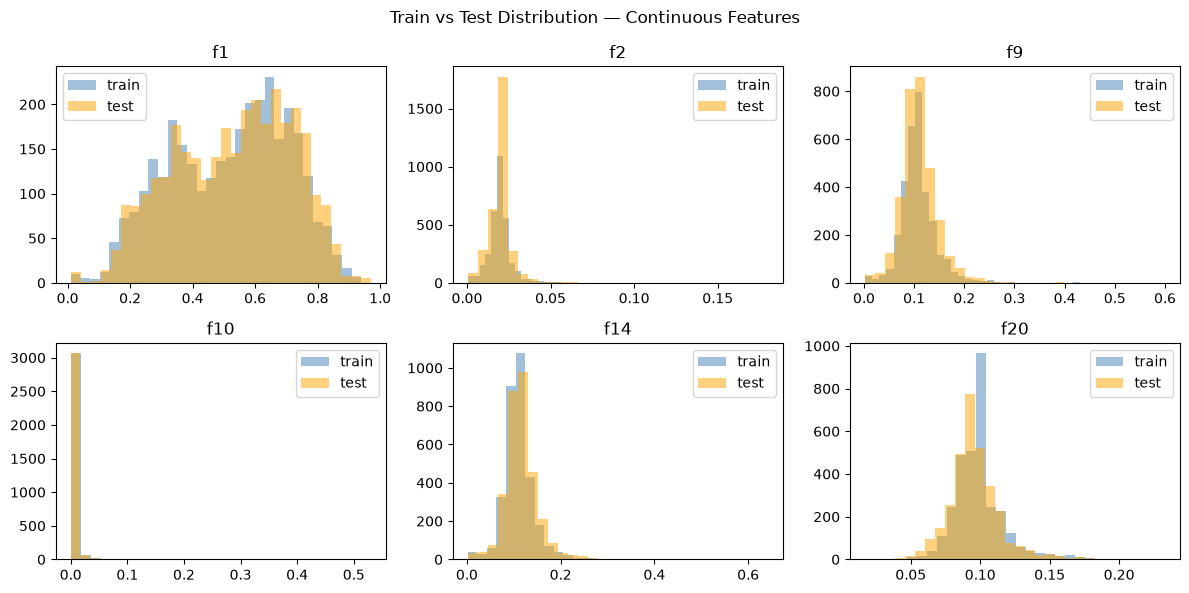

In [23]:
  fig, axes = plt.subplots(2, 3, figsize=(12, 6))                                                     
  axes = axes.flatten()

  for i, col in enumerate(continuous_cols):
      axes[i].hist(train[col], bins=30, alpha=0.5, label='train', color='steelblue')
      axes[i].hist(test[col], bins=30, alpha=0.5, label='test', color='orange')
      axes[i].set_title(col)
      axes[i].legend()

  plt.suptitle('Train vs Test Distribution — Continuous Features')
  plt.tight_layout()
  plt.show()

In [24]:
  binary_cols_valid = [col for col in binary_cols if col != 'f19']                                    

  train_means = train[binary_cols_valid].mean()
  test_means = test[binary_cols_valid].mean()

  comparison = pd.DataFrame({'train': train_means, 'test': test_means})
  comparison['difference'] = (comparison['train'] - comparison['test']).abs().round(4)
  comparison.round(4)

,train,test,difference
f3,0.0450,0.0466,0.0016
f4,0.3012,0.3025,0.0012
f5,0.0147,0.0191,0.0044
f6,0.0388,0.0372,0.0016
f7,0.0050,0.0209,0.0159
f8,0.0122,0.0184,0.0062
f11,0.0253,0.0269,0.0016
f12,0.1228,0.1394,0.0166
f13,0.0619,0.0697,0.0078
f15,0.0112,0.0141,0.0028


## EDA Summary

**Dataset:** 3200 train rows, 3200 test rows, 21 features, no missing values.

**Feature types:**

- 6 continuous features: f1, f2, f9, f10, f14, f20
- 15 binary (0/1) features: f3-f8, f11-f13, f15-f19, f21

**Key findings:**

- **Severe class imbalance:** class3=91%, class2=6%, class1=3% → use macro-F1, not accuracy
- **f19 to drop:** only 1 non-zero value in train, always 0 in test → useless
- **Best discriminating features:** f10 (strong for class1), f9 and f14 (correlated at 0.78, strong for class3 vs class1)
- **f9 and f14 are highly correlated (0.78)** – redundant but harmless for LightGBM
- **No distribution shift** between train and test – local CV should be reliable

**Preprocessing plan:**

- Drop f19 and ID
- No missing value imputation needed
- No scaling needed (LightGBM is tree-based)
- Use stratified k-fold CV to handle class imbalance